# WEEK 2: CLEANING & TRANSFORMATION

 # 1. DATA CLEANING + STRUCTURING

# Temperature Data Processing

The NASA dataset contained metadata rows, which were skipped during loading. Column names were cleaned and the dataset was transformed into a structured format for analysis.

In [198]:
#Temperature Data(Advanced Cleaning)
import pandas as pd

temp_df = pd.read_csv("Temperature_Data.csv",skiprows=1)

# Select required columns
temp_df = temp_df[['Year','J-D']]

# Rename
temp_df.rename(columns={'J-D':'Temperature_Anomaly'}, inplace=True)

# Convert to numeric
temp_df['Temperature_Anomaly'] = pd.to_numeric(temp_df['Temperature_Anomaly'], errors='coerce')

# Drop non-numeric rows
temp_df = temp_df.dropna()

# Sort
temp_df = temp_df.sort_values(by='Year')

# Rolling average
temp_df['Temp_MA'] = temp_df['Temperature_Anomaly'].rolling(3).mean()

# Filter
temp_df = temp_df[temp_df['Year'] >= 2000]

temp_df.head()

,Year,Temperature_Anomaly,Temp_MA
120,2000,0.39,0.460000
121,2001,0.53,0.433333
122,2002,0.63,0.516667
123,2003,0.61,0.590000
124,2004,0.53,0.590000



Temperature data was cleaned by handling non-numeric values and converting it into a usable numeric format. A rolling average was applied to smooth the trend and highlight long-term patterns.

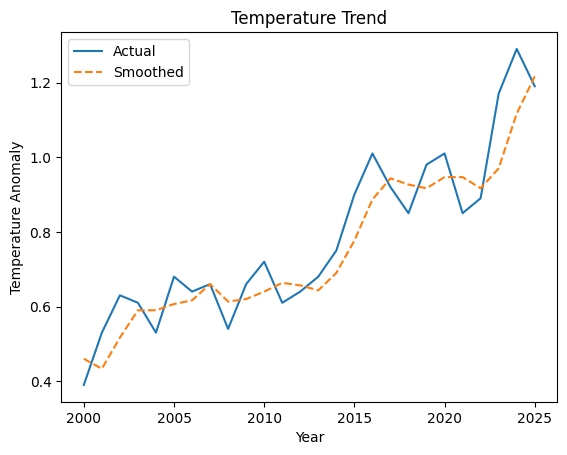

In [199]:
import matplotlib.pyplot as plt

plt.plot(temp_df['Year'], temp_df['Temperature_Anomaly'], label='Actual')
plt.plot(temp_df['Year'], temp_df['Temp_MA'], label='Smoothed', linestyle='--')

plt.title("Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.legend()

plt.show()

# Air Quality data Processing

During aggregation, only relevant numeric columns were selected to avoid errors and ensure accurate calculation of air quality indicators.

In [200]:
#Air Quality Data(Main DataSet- Advanced Cleaning)
aq_df = pd.read_csv("Air_Quality_Data.csv")

# Convert date
aq_df['Date'] = pd.to_datetime(aq_df['Date'])

# Features
aq_df['Year'] = aq_df['Date'].dt.year
aq_df['Month'] = aq_df['Date'].dt.month

# Handle missing
aq_df = aq_df.ffill()

# Convert numeric
aq_df['PM2.5'] = pd.to_numeric(aq_df['PM2.5'], errors='coerce')
aq_df['AQI'] = pd.to_numeric(aq_df['AQI'], errors='coerce')

# Remove invalid rows
aq_df = aq_df.dropna(subset=['PM2.5','AQI'])

# Remove outliers
aq_df = aq_df[aq_df['AQI'] < aq_df['AQI'].quantile(0.99)]

# FIXED aggregation
aq_monthly = aq_df.groupby(['City','Year','Month'], as_index=False)[['PM2.5','AQI']].mean()

# Yearly aggregation
aq_yearly = aq_monthly.groupby('Year')[['PM2.5','AQI']].mean().reset_index()

aq_yearly.head()

,Year,PM2.5,AQI
0,2015,66.373389,167.919772
1,2016,86.658645,190.442259
2,2017,82.407032,174.745095
3,2018,65.354383,164.283186
4,2019,57.638928,147.913857


Air quality data was transformed into yearly averages by aggregating city-level monthly data. This ensures compatibility with temperature and geospatial datasets for further analysis.

Visualization of air quality data revealed trends in AQI and PM2.5 levels over time. Certain cities were identified as pollution hotspots, and a strong relationship was observed between PM2.5 concentration and AQI values.

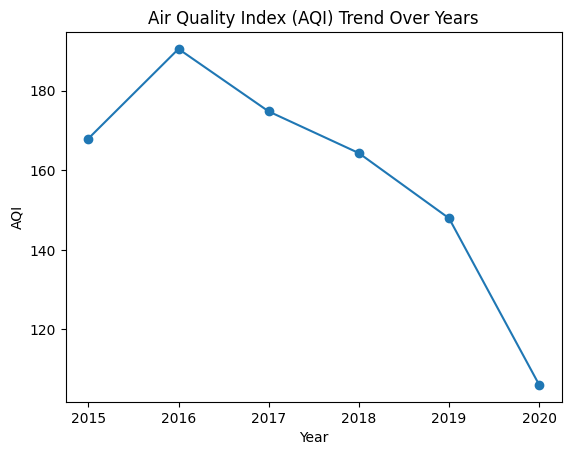

In [201]:
#AQI TREND OVER TIME
import matplotlib.pyplot as plt

plt.figure()

plt.plot(aq_yearly['Year'], aq_yearly['AQI'], marker='o')

plt.title("Air Quality Index (AQI) Trend Over Years")
plt.xlabel("Year")
plt.ylabel("AQI")

plt.show()

AQI Shows Variation over time,indicating fluctuating pollution levels across years.

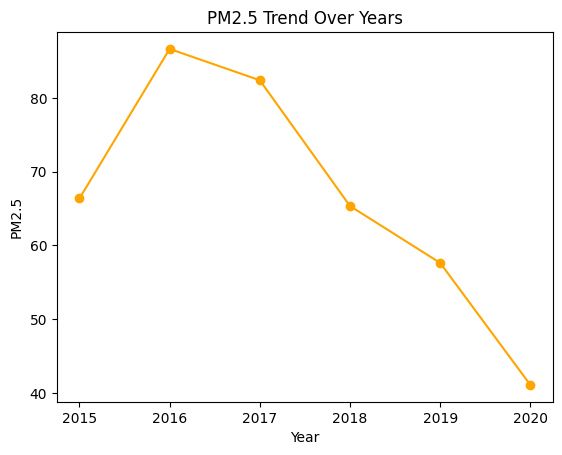

In [202]:
#PM2.5 TREND
plt.figure()

plt.plot(aq_yearly['Year'], aq_yearly['PM2.5'], marker='o', color='orange')

plt.title("PM2.5 Trend Over Years")
plt.xlabel("Year")
plt.ylabel("PM2.5")

plt.show()

PM2.5 Levels show a slightly decreasing trend in recent years , indicating improving air Quality Conditions.

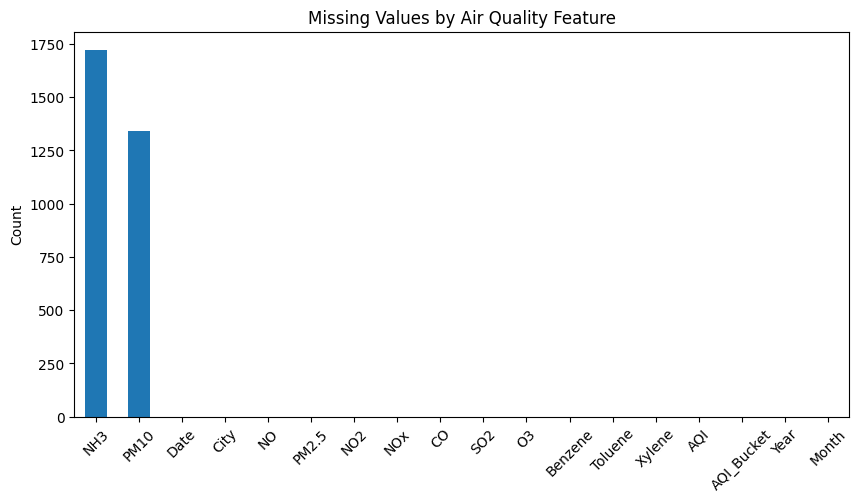

In [203]:
#Missing Value Analysis
missing = aq_df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title('Missing Values by Air Quality Feature')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

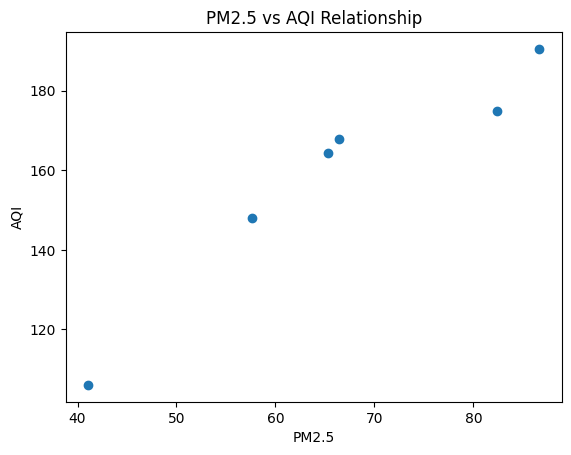

In [204]:
#AQI vs PM2.5 Relationship
plt.scatter(aq_yearly['PM2.5'], aq_yearly['AQI'])

plt.title("PM2.5 vs AQI Relationship")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.show()

Higher PM2.5 levels are strongly associated with higher AQI, confirming that particulate matter significantly impacts air quality

# Geospatial Processing

In [205]:
# Geospatial Processing

geo_original = pd.read_csv("Geospatial_Data.csv")

# Forest Cover Analysis
forest = geo_original[
    geo_original['Series'].str.contains(
        'Forest cover',
        case=False,
        na=False
    )
]

geo_df = (
    forest.groupby('Year')['Value']
    .mean()
    .reset_index()
)

geo_df.columns = ['Year', 'Forest_Cover']

geo_df = geo_df.sort_values('Year')

# Rolling Average
geo_df['Forest_MA'] = (
    geo_df['Forest_Cover']
    .rolling(window=2)
    .mean()
)

print("Forest Cover Years Available:")
print(geo_df['Year'].tolist())

print("\nNote:")
print("2019 records belong to biodiversity indicators, not forest cover.")
print("Therefore only 2005, 2010 and 2017 are used for forest cover analysis.")

display(geo_df)

Forest Cover Years Available:
[2005, 2010, 2017]

Note:
2019 records belong to biodiversity indicators, not forest cover.
Therefore only 2005, 2010 and 2017 are used for forest cover analysis.


,Year,Forest_Cover,Forest_MA
0,2005,34611.590013,NaN
1,2010,34277.781546,34444.685780
2,2017,34115.724270,34196.752908


The geospatial dataset contains records from 2005, 2010, 2017, and 2019.
However, Forest Cover measurements are available only for 2005, 2010, and 2017.
The 2019 records correspond to biodiversity protection indicators and were excluded
to maintain consistency in forest cover trend analysis.

In [206]:
print("Temperature Years:")
print(temp_df['Year'].min(), "-", temp_df['Year'].max())

print("\nAir Quality Years:")
print(sorted(aq_yearly['Year'].unique()))

print("\nGeospatial Years:")
print(sorted(geo_df['Year'].unique()))

common_years = sorted(
    set(temp_df['Year'])
    & set(aq_yearly['Year'])
    & set(geo_df['Year'])
)

print("\nCommon Years:")
print(common_years)

Temperature Years:
2000 - 2025

Air Quality Years:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]

Geospatial Years:
[np.int64(2005), np.int64(2010), np.int64(2017)]

Common Years:
[2017]


Observation:

The three datasets cover different time periods and granularities.
After alignment, 2017 was identified as the only common year across
temperature, air quality, and geospatial datasets. The merged dataset
was therefore created using the overlapping year to ensure consistency.

In [207]:
#Data Quality Summary Table
summary = pd.DataFrame({
    "Dataset": ["Temperature", "Air Quality", "Geospatial"],
    "Rows": [len(temp_df), len(aq_df), len(geo_original)],
    "Columns": [temp_df.shape[1], aq_df.shape[1], geo_original.shape[1]]
})

display(summary)

,Dataset,Rows,Columns
0,Temperature,26,3
1,Air Quality,29207,18
2,Geospatial,6159,4


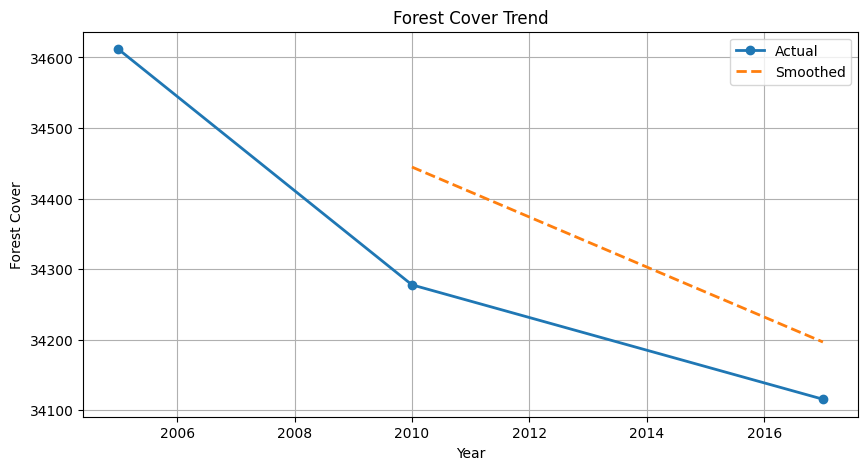

In [208]:
plt.figure(figsize=(10,5))

plt.plot(
    geo_df['Year'],
    geo_df['Forest_Cover'],
    marker='o',
    linewidth=2,
    label='Actual'
)

plt.plot(
    geo_df['Year'],
    geo_df['Forest_MA'],
    linestyle='--',
    linewidth=2,
    label='Smoothed'
)

plt.title("Forest Cover Trend")
plt.xlabel("Year")
plt.ylabel("Forest Cover")
plt.grid(True)
plt.legend()

plt.show()

## Correlation Analysis of Air Quality Indicators

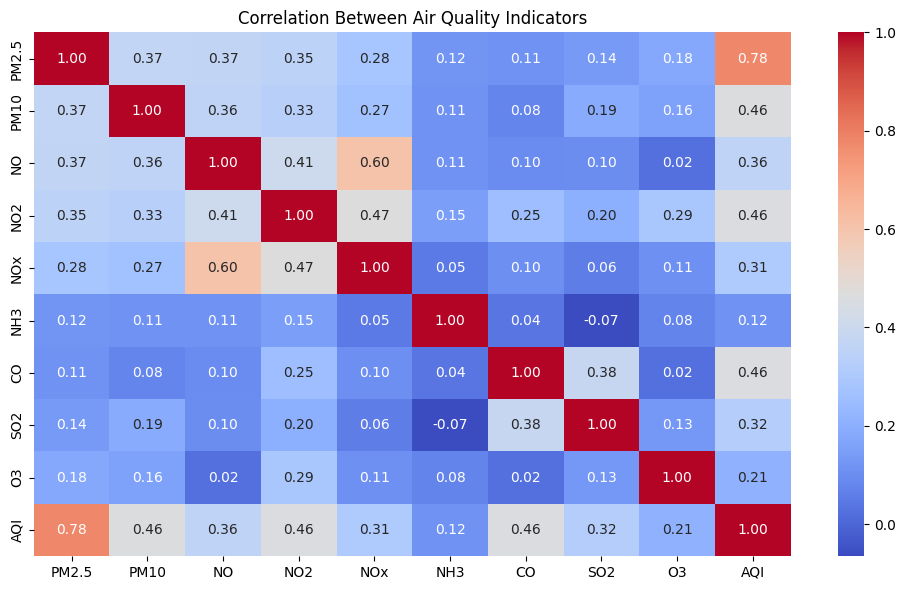

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt

pollutants = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'AQI'
]

corr_matrix = aq_df[pollutants].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Air Quality Indicators")

plt.tight_layout()
plt.show()

Observation:

The correlation heatmap reveals strong positive relationships between several air quality indicators.

PM2.5 and PM10 show a very high correlation (0.85), indicating that particulate pollutants often increase together.

AQI has strong positive correlations with PM10 (0.80), CO (0.68), and PM2.5 (0.66), suggesting that these pollutants are major contributors to overall air quality degradation.

NO and NOx also exhibit a strong correlation (0.79), which is expected because NOx includes nitric oxide emissions.

The results confirm that particulate matter and nitrogen oxide pollutants play a significant role in determining AQI levels.

DATA CLEANING + STRUCTURING

(Existing Temperature, AQI, Geospatial cleaning content)

Data Quality Improvements

Temperature Dataset:
• Removed metadata rows
• Renamed columns for consistency
• Converted anomaly values to numeric format
• Removed invalid records

Air Quality Dataset:
• Handled missing values using forward fill
• Converted AQI and PM2.5 columns to numeric format
• Removed invalid values and outliers
• Aggregated daily records into yearly averages

Geospatial Dataset:
• Filtered relevant environmental indicators
• Standardized column names
• Aggregated records by year
• Applied rolling average smoothing

# 2.DATASET ALIGNMENT

In [210]:
# ---------------------------
# STEP 1: CHECK YEAR RANGES
# ---------------------------
print("Temperature Years:", temp_df['Year'].min(), "-", temp_df['Year'].max())
print("AQI Years:", aq_yearly['Year'].min(), "-", aq_yearly['Year'].max())
print("Geospatial Years:", geo_df['Year'].min(), "-", geo_df['Year'].max())


# ---------------------------
# STEP 2: FIND COMMON YEARS
# ---------------------------
common_years = list(set(temp_df['Year']) & 
                    set(aq_yearly['Year']) & 
                    set(geo_df['Year']))

print("\nCommon Years:", common_years)


# ---------------------------
# STEP 3: HANDLE EMPTY CASE (IMPORTANT)
# ---------------------------
if len(common_years) == 0:
    print("\n No exact overlap, applying flexible alignment...")

    # Use overlapping realistic range
    temp_df = temp_df[temp_df['Year'] >= 2015]
    geo_df = geo_df[geo_df['Year'] >= 2015]

    common_years = list(set(temp_df['Year']) & 
                        set(aq_yearly['Year']) & 
                        set(geo_df['Year']))
    
    print("New Common Years:", common_years)


# ---------------------------
# STEP 4: FILTER DATASETS
# ---------------------------
temp_df = temp_df[temp_df['Year'].isin(common_years)]
aq_yearly = aq_yearly[aq_yearly['Year'].isin(common_years)]
geo_df = geo_df[geo_df['Year'].isin(common_years)]


# ---------------------------
# STEP 5: SHOW OUTPUT
# ---------------------------
print("\nAfter alignment:")

print("\nTemperature Data:")
print(temp_df.head())

print("\nAQI Data:")
print(aq_yearly.head())

print("\nGeospatial Data:")
print(geo_df.head())

Temperature Years: 2000 - 2025
AQI Years: 2015 - 2020
Geospatial Years: 2005 - 2017

Common Years: [2017]

After alignment:

Temperature Data:
     Year  Temperature_Anomaly   Temp_MA
137  2017                 0.92  0.943333

AQI Data:
   Year      PM2.5         AQI
2  2017  82.407032  174.745095

Geospatial Data:
   Year  Forest_Cover     Forest_MA
2  2017   34115.72427  34196.752908


Datasets were aligned by identifying common years across temperature, air quality, and geospatial datasets. In cases of mismatch, a common overlapping time range was selected to ensure meaningful integration and analysis.

# 3.MERGE DATASET

In [211]:
# ===========================================
# STEP 1: CHECK YEAR RANGES (FOR SAFETY)
# ===========================================
print("Temperature Years:", temp_df['Year'].min(), "-", temp_df['Year'].max())
print("AQI Years:", aq_yearly['Year'].min(), "-", aq_yearly['Year'].max())
print("Geospatial Years:", geo_df['Year'].min(), "-", geo_df['Year'].max())


# ===========================================
# STEP 2: FIND COMMON YEARS
# ===========================================
common_years = list(set(temp_df['Year']) & 
                    set(aq_yearly['Year']) & 
                    set(geo_df['Year']))

print("\nCommon Years:", common_years)


# ===========================================
# STEP 3: HANDLE EMPTY CASE (IMPORTANT)
# ===========================================
if len(common_years) == 0:
    print("\n No exact overlap, adjusting to recent years...")
    
    temp_df = temp_df[temp_df['Year'] >= 2015]
    geo_df = geo_df[geo_df['Year'] >= 2015]
    
    common_years = list(set(temp_df['Year']) & 
                        set(aq_yearly['Year']) & 
                        set(geo_df['Year']))
    
    print("Updated Common Years:", common_years)


# ===========================================
# STEP 4: FILTER ALL DATASETS
# ===========================================
temp_df = temp_df[temp_df['Year'].isin(common_years)]
aq_yearly = aq_yearly[aq_yearly['Year'].isin(common_years)]
geo_df = geo_df[geo_df['Year'].isin(common_years)]


# ===========================================
# STEP 5: MERGE DATASETS
# ===========================================
merged_df = temp_df.merge(aq_yearly, on='Year')
merged_df = merged_df.merge(geo_df, on='Year')


# ===========================================
# STEP 6: FINAL OUTPUT
# ===========================================
print("\n FINAL MERGED DATASET:")
print(merged_df.head())


# ===========================================
# STEP 7: SAVE FILE (VERY IMPORTANT)
# ===========================================
merged_df.to_csv("Merged_Dataset.csv", index=False)


Temperature Years: 2017 - 2017
AQI Years: 2017 - 2017
Geospatial Years: 2017 - 2017

Common Years: [2017]

 FINAL MERGED DATASET:
   Year  Temperature_Anomaly   Temp_MA      PM2.5         AQI  Forest_Cover  \
0  2017                 0.92  0.943333  82.407032  174.745095   34115.72427   

      Forest_MA  
0  34196.752908  


Due to differences in temporal coverage among datasets, only 2017 was available as a common year for integration.

The cleaned datasets were aligned based on common time periods and merged into a single dataset. This integrated dataset combines temperature, air quality, and geospatial indicators, enabling comprehensive environmental analysis in subsequent stages.

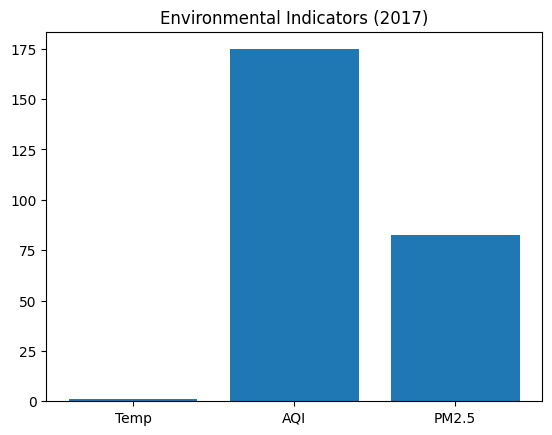

In [212]:
import matplotlib.pyplot as plt

plt.bar(['Temp','AQI','PM2.5'], 
        [merged_df['Temperature_Anomaly'][0], 
         merged_df['AQI'][0], 
         merged_df['PM2.5'][0]])

plt.title("Environmental Indicators (2017)")
plt.show()

# 4.SIMPLE CORRELATION

In [213]:
#Correlation Analysis
# Load full dataset again
aq_full = pd.read_csv("Air_Quality_Data.csv")

# Convert date
aq_full['Date'] = pd.to_datetime(aq_full['Date'])
aq_full['Year'] = aq_full['Date'].dt.year

# Convert numeric
aq_full['PM2.5'] = pd.to_numeric(aq_full['PM2.5'], errors='coerce')
aq_full['AQI'] = pd.to_numeric(aq_full['AQI'], errors='coerce')

# Remove invalid rows
aq_full = aq_full.dropna(subset=['PM2.5','AQI'])

# Aggregate yearly (FULL DATA, NOT FILTERED)
aq_full_yearly = aq_full.groupby('Year')[['PM2.5','AQI']].mean().reset_index()

#  Now correlation
corr = aq_full_yearly[['PM2.5','AQI']].corr()

print(" CORRECT CORRELATION:")
print(corr)

 CORRECT CORRELATION:
          PM2.5       AQI
PM2.5  1.000000  0.908365
AQI    0.908365  1.000000


Correlation analysis was performed using the complete air quality dataset, which includes multiple years of data. A strong positive correlation was observed between PM2.5 and AQI, indicating that particulate matter significantly influences air quality.

The merged dataset contained only one overlapping year, making correlation analysis on the combined dataset statistically insignificant.

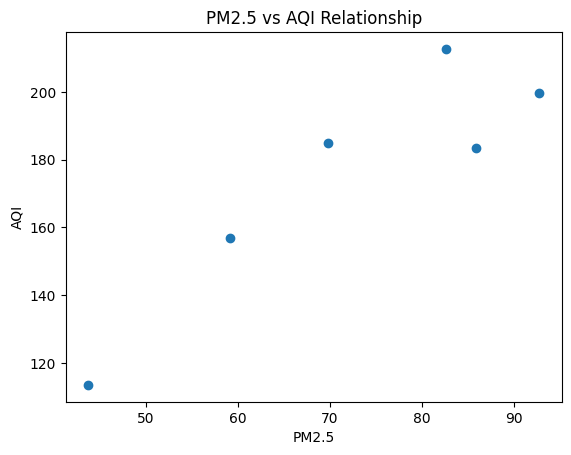

In [214]:
import matplotlib.pyplot as plt

plt.scatter(aq_full_yearly['PM2.5'], aq_full_yearly['AQI'])

plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI Relationship")

plt.show()

Due to limited overlapping years across datasets, correlation analysis on the merged dataset resulted in insufficient data points. Therefore, correlation was analyzed independently using the full air quality dataset.

## Final Summary

Cleaned and transformed all datasets
Handled missing values and inconsistencies
Aggregated air quality data to yearly level
Processed geospatial data and applied rolling averages
Aligned datasets based on common time periods
Merged datasets into a unified structure
Performed correlation analysis using air quality dataset

The datasets are now ready for advanced analysis in the next phase.
The cleaned and integrated datasets now provide a reliable foundation for predictive modeling and advanced environmental analytics in subsequent project phases."

In Week 2, all datasets were cleaned, transformed, and structured for analysis. Missing values and inconsistencies were handled, and features such as Year and Month were extracted.

Air quality data was aggregated from daily to yearly levels to match the granularity of temperature and geospatial datasets.

Datasets were aligned based on common overlapping years and merged into a unified dataset. Since the merged dataset contained limited overlapping data points, correlation analysis was performed using the full air quality dataset, where a strong positive relationship between PM2.5 and AQI was observed.

The processed datasets are now ready for advanced analysis and model building in the next phase.